In [1]:
import metview as mv

In [2]:
# getting data
use_mars = True

In [ ]:
# Retrieve co2 at surface 
clwc = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-18",
        expver="iyw7",
        levtype = "srf",
        param = "co2",
        date = -1,
        grid = [2,2]
        )

In [ ]:
# Retrieve tendencies
clwc = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-18",
        expver="iyw7",
        levtype = "ml",
        levelist = [1,"to",2],
        param = "clwc",
        date = -1,
        grid = [2,2]
        )

# Retrieve lnsp
lnsp = mv.retrieve(
   levtype = "ml",
   levelist = 1,
   param = "lnsp",
   date = -1,
   grid = [2,2]
)

print(f"Integrating tendencies to obtain fluxes:")
r = mv.univertint(lnsp,clwc)


Integrating tendencies to obtain fluxes:


NameError: name 'ds_ml' is not defined

Could not import ipywidgets module - animation widget will not appear
Call setoutput('jupyter', plot_widget=False) to suppress this message


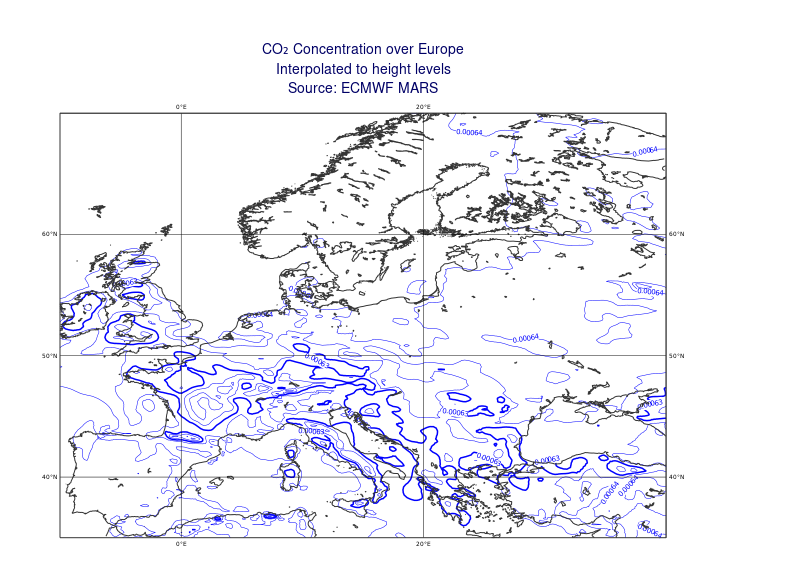

In [3]:

# Retrieve CO2 data from MARS (on model levels)
if use_mars:
    retrieval = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-15",
        expver="io1d",
        levelist=[125],  # Model level 125
        levtype="ml",    # Model levels
        param="210061",  # CO2 variable
        step=[12],
        stream="lwda",
        time="00:00:00",
        type="fc"
    )
# reading data from file or getting from data server
else:
    filename = "fc_msl_io1d.grib"
    if mv.exist(filename):
        g = mv.read(filename)
    else:
        g = mv.gallery.load_dataset(filename)

# # Read the retrieved field (ensure Metview handles it correctly)
# co2_field = mv.read(retrieval)

# # Convert model levels to height levels (if required)
# co2_field_hl = mv.mvl_ml_to_hl(co2_field)

# Define a geographical view (Europe)
view = mv.geoview(
    map_area_definition="corners",
    area=[35, -10, 70, 40],  # [South, West, North, East]
    coastlines=mv.mcoast(
        map_coastline_thickness=2,
        map_coastline_colour="charcoal",
        map_coastline_resolution="high"
    )
)

# Define the colour scale for CO2 concentrations
contour = mv.mcont(
    contour_automatic_setting="ecmwf",
    contour_shade="on",
)

# # define contouring for msl
# contour = mv.mcont(
#     contour_line_thickness=2,
#     contour_line_colour="charcoal",
#     contour_highlight="off",
#     contour_highlight_colour="charcoal",
#     contour_highlight_thickness=4,
#     contour_level_selection_type="interval",
#     contour_interval=5,
#     contour_label_height=0.2,
#     grib_scaling_of_derived_fields="on",
# )

# Define the title
title = mv.mtext(
    text_lines=["CO₂ Concentration over Europe", "Interpolated to height levels", "Source: ECMWF MARS"],
    text_font_size=0.6,
    text_colour="navy"
)

# Generate the plot
mv.plot(view, retrieval, contour, title)



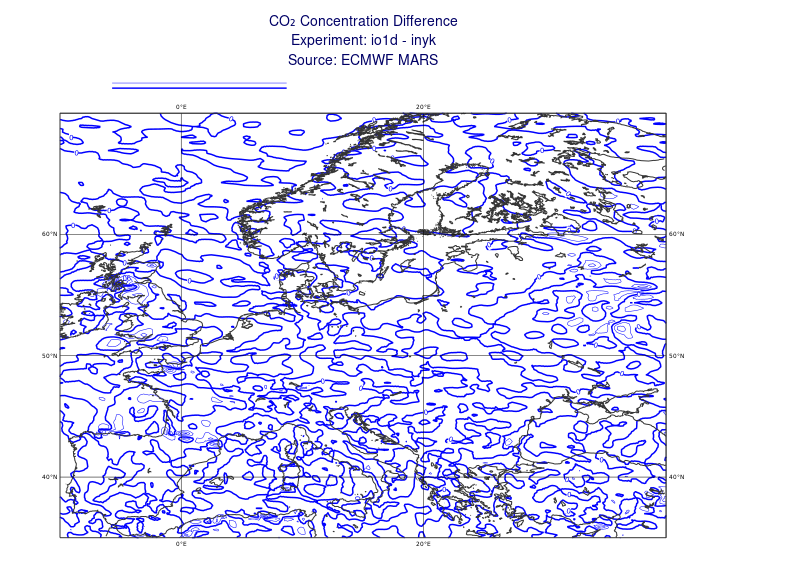

In [4]:
# Use flag to decide whether to use data from MARS or a local file
use_mars = True

# Retrieve CO2 data from MARS (on model levels) for 'io1d' experiment
if use_mars:
    retrieval_io1d = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-15",
        expver="io1d",
        levelist=[125],  # Model level 125
        levtype="ml",    # Model levels
        param="210061",  # CO2 variable
        step=[12],
        stream="lwda",
        time="00:00:00",
        type="fc"
    )
else:
    filename_io1d = "fc_msl_io1d.grib"
    retrieval_io1d = mv.read(filename_io1d)

# Retrieve CO2 data from MARS (on model levels) for 'inyk' experiment
if use_mars:
    retrieval_inyk = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-15",
        expver="inyk",  # 'inyk' experiment
        levelist=[125],  # Model level 125
        levtype="ml",    # Model levels
        param="210061",  # CO2 variable
        step=[12],
        stream="lwda",
        time="00:00:00",
        type="fc"
    )
else:
    filename_inyk = "fc_msl_inyk.grib"
    retrieval_inyk = mv.read(filename_inyk)

# Calculate the difference between the two experiments
co2_difference = retrieval_io1d - retrieval_inyk

# Define a geographical view (Europe)
view = mv.geoview(
    map_area_definition="corners",
    area=[35, -10, 70, 40],  # [South, West, North, East]
    coastlines=mv.mcoast(
        map_coastline_thickness=2,
        map_coastline_colour="charcoal",
        map_coastline_resolution="high"
    )
)

# Define the colour scale for the CO2 concentration difference
contour = mv.mcont(
    contour_automatic_setting="ecmwf",
    contour_shade="on",
)

eccharts_contouring = mv.mcont(
    contour_automatic_setting = "ecmwf",
    legend                    = "on"
    )


# Define the title
title = mv.mtext(
    text_lines=["CO₂ Concentration Difference", "Experiment: io1d - inyk", "Source: ECMWF MARS"],
    text_font_size=0.6,
    text_colour="navy"
)

# Generate the plot for the difference between the two experiments
mv.plot(view, co2_difference, eccharts_contouring, title)


In [43]:
# Use flag to decide whether to use data from MARS or a local file
use_mars = True

# Retrieve CO2 data from MARS (on model levels) for 'io1d' experiment
if use_mars:
    retrieval_io1d = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-15",
        expver="io1d",
        levelist=[125],  # Model level 125
        levtype="ml",    # Model levels
        param="u",  # CO2 variable
        step=[12],
        stream="lwda",
        time="00:00:00",
        type="fc"
    )
else:
    filename_io1d = "fc_msl_io1d.grib"
    retrieval_io1d = mv.read(filename_io1d)

# Retrieve CO2 data from MARS (on model levels) for 'inyk' experiment
if use_mars:
    retrieval_inyk = mv.retrieve(
        anoffset=9,
        class_="rd",
        date="2022-05-15",
        expver="inii",  # 'inii' experiment
        levelist=[125],  # Model level 125
        levtype="ml",    # Model levels
        param="u",  # CO2 variable
        step=[12],
        stream="lwda",
        time="00:00:00",
        type="fc"
    )
else:
    filename_inyk = "fc_msl_inyk.grib"
    retrieval_inyk = mv.read(filename_inyk)

# Calculate the difference between the two experiments
co2_difference = retrieval_io1d - retrieval_inyk

# Define a geographical view (Europe)
view = mv.geoview(
    map_area_definition="corners",
    area=[35, -10, 70, 40],  # [South, West, North, East]
    coastlines=mv.mcoast(
        map_coastline_thickness=2,
        map_coastline_colour="charcoal",
        map_coastline_resolution="high"
    )
)

# Define the shading for the CO2 concentration difference
# contour = mv.mcont(
#     contour_automatic_setting="ecmwf",
#     contour_shade="on",  # Enable shading
# )
contour = mv.mcont(
    contour="off",
    contour_level_selection_type="level_list",
    contour_level_list=[-0.00001, -0.0000001, 0, 0.0000001, 0.00001],
    contour_label="on",
    contour_shade="on",
    contour_shade_colour_method="list",
    contour_shade_method="area_fill",
    contour_shade_colour_list=[
        "RGB(0.5374,0.6855,0.9606)",
        "RGB(0.1259,0.5569,0.9878)",
        "white",
        "avocado",
        "yellowish_orange",
    ],
)

# Define the title
title = mv.mtext(
    text_lines=["CO₂ Concentration Difference", "Experiment: io1d - inyk", "Source: ECMWF MARS"],
    text_font_size=0.6,
    text_colour="navy"
)

my_legend = mv.mlegend(
    legend_title="ON",
    legend_box_mode="POSITIONAL",
    legend_box_x_position=26.00,
    legend_box_x_length=2.00,
    legend_box_y_position=2.00,
    legend_box_y_length=10.00,
    legend_display_type="CONTINUOUS",
    legend_border="OFF",
    legend_text_font_size=0.50,
    legend_text_colour="NAVY",
    legend_title_text="850hpa Temperature",
    legend_title_orientation="VERTICAL",
)

# Generate the plot for the difference between the two experiments
mv.plot(view, co2_difference, contour, my_legend, title)


: 